In [11]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

In [12]:
df = yf.download("RELIANCE.NS", start="2011-01-01", end="2024-01-01",auto_adjust=True)
df = df.droplevel("Ticker", axis=1)
train = df[:"2020-12-31"]  # Jan 2011 – Dec 2020 (10 years)
test  = df["2021-01-01":]  # Jan 2021 – Jan 2024  (3 years)

[*********************100%***********************]  1 of 1 completed


In [13]:
def create_target(data, horizon=5):
    # Binary target: 1 if Close(T+horizon) > Close(T), else 0.
    if isinstance(data.columns, pd.MultiIndex):
        data = data.droplevel("Ticker", axis=1)
    close = data["Close"]
    future_close = close.shift(-horizon)
    target = (future_close > close).astype(int)
    target.name = "target"
    return target


In [14]:
def build_features(data):
    """Engineer features from OHLCV data."""
    if isinstance(data.columns, pd.MultiIndex):
        data = data.droplevel("Ticker", axis=1)

    close = data["Close"]
    volume = data["Volume"]
    feat = pd.DataFrame(index=data.index)

    # Price returns
    feat["ret_1"]  = close.pct_change(1)
    feat["ret_5"]  = close.pct_change(5)
    feat["ret_10"] = close.pct_change(10)
    feat["ret_20"] = close.pct_change(20)

    # Moving average ratios
    feat["ma5_ratio"]  = close / close.rolling(5).mean()
    feat["ma10_ratio"] = close / close.rolling(10).mean()
    feat["ma20_ratio"] = close / close.rolling(20).mean()
    feat["ma50_ratio"] = close / close.rolling(50).mean()

    # Volatility
    feat["vol_5"]  = close.pct_change().rolling(5).std()
    feat["vol_20"] = close.pct_change().rolling(20).std()

    # RSI (14-day)
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    feat["rsi_14"] = 100 - (100 / (1 + rs))

    # Volume change
    feat["vol_change_1"] = volume.pct_change(1)
    feat["vol_change_5"] = volume.pct_change(5)

    # Rolling Z-scores
    feat["zscore_20"] = (close - close.rolling(20).mean()) / close.rolling(20).std()
    feat["zscore_50"] = (close - close.rolling(50).mean()) / close.rolling(50).std()

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    feat["macd"] = macd_line / close
    feat["macd_signal"] = signal_line / close
    feat["macd_hist"] = (macd_line - signal_line) / close

    # Bollinger Bands (20-day)
    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    feat["bb_upper_ratio"] = close / bb_upper
    feat["bb_lower_ratio"] = close / bb_lower
    feat["bb_bandwidth"] = (bb_upper - bb_lower) / bb_mid

    # ATR (Average True Range, 14-day)
    high = data["High"]
    low = data["Low"]
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    feat["atr_14"] = true_range.rolling(14).mean() / close

    feat.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feat

In [15]:
# ---- Prepare data for modeling ----
X_train = build_features(train)
y_train = create_target(train, horizon=5)
X_test  = build_features(test)
y_test  = create_target(test, horizon=5)

# Drop NaN rows
train_combined = pd.concat([X_train, y_train], axis=1).dropna()
test_combined  = pd.concat([X_test, y_test], axis=1).dropna()

X_train_clean = train_combined.drop('target', axis=1)
y_train_clean = train_combined['target']
X_test_clean  = test_combined.drop('target', axis=1)
y_test_clean  = test_combined['target']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled  = scaler.transform(X_test_clean)

print('X_train shape:', X_train_scaled.shape)
print('X_test shape: ', X_test_scaled.shape)
print('Target distribution (train):', y_train_clean.value_counts().to_dict())

X_train shape: (2410, 22)
X_test shape:  (692, 22)
Target distribution (train): {1: 1290, 0: 1120}


In [16]:
# ---- Train Random Forest (baseline) ----
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train_clean)

# Predict
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Results
print("--- Train Set ---")
print("Accuracy:", round(accuracy_score(y_train_clean, y_train_pred), 4))
print(classification_report(y_train_clean, y_train_pred, target_names=["Down/Flat", "Up"]))

print("--- Test Set ---")
print("Accuracy:", round(accuracy_score(y_test_clean, y_test_pred), 4))
print(classification_report(y_test_clean, y_test_pred, target_names=["Down/Flat", "Up"]))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test_clean, y_test_pred))

# Feature importances
importances = pd.Series(model.feature_importances_, index=X_train_clean.columns)
print("\nFeature Importances:")
print(importances.sort_values(ascending=False).to_string())

--- Train Set ---
Accuracy: 0.8772
              precision    recall  f1-score   support

   Down/Flat       0.91      0.82      0.86      1120
          Up       0.85      0.93      0.89      1290

    accuracy                           0.88      2410
   macro avg       0.88      0.87      0.88      2410
weighted avg       0.88      0.88      0.88      2410

--- Test Set ---
Accuracy: 0.5535
              precision    recall  f1-score   support

   Down/Flat       0.53      0.42      0.47       324
          Up       0.57      0.67      0.61       368

    accuracy                           0.55       692
   macro avg       0.55      0.55      0.54       692
weighted avg       0.55      0.55      0.55       692

Confusion Matrix (Test):
[[137 187]
 [122 246]]

Feature Importances:
vol_20            0.068306
atr_14            0.066299
ma50_ratio        0.056131
macd_signal       0.055057
vol_5             0.055044
ret_20            0.051188
ret_10            0.047876
macd              

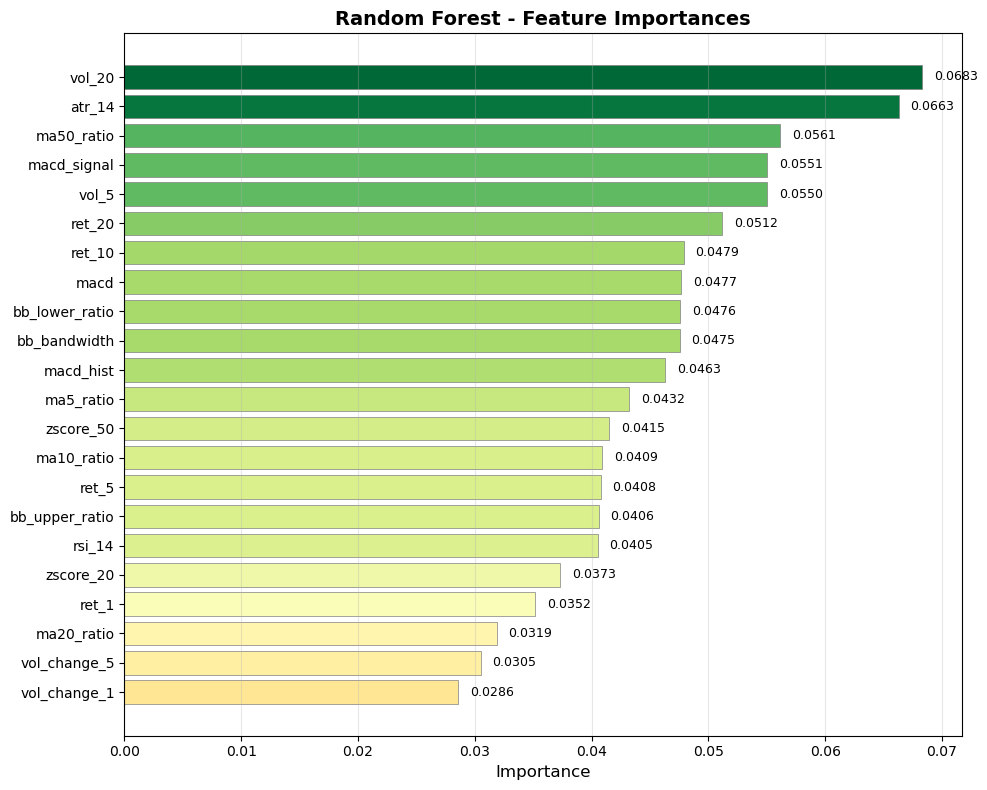

Plot saved to: feature_importance.png


In [17]:
# ---- Feature Importance Bar Chart ----
importances = pd.Series(model.feature_importances_, index=X_train_clean.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(importances / importances.max())
ax.barh(importances.index, importances.values, color=colors, edgecolor='gray', linewidth=0.5)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest - Feature Importances', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to: feature_importance.png')

In [18]:
# ---- Hyperparameter Tuning with Optuna ----

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(rf, X_train_scaled, y_train_clean, cv=tscv, scoring="accuracy", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=30))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
print("  Accuracy:", round(study.best_value, 4))
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial:
  Accuracy: 0.5491
  Params:
    n_estimators: 200
    max_depth: 14
    min_samples_split: 46
    min_samples_leaf: 20
    max_features: None


In [19]:
# ---- Evaluate best model from tuning ----
best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train_scaled, y_train_clean)

y_test_pred_best = best_model.predict(X_test_scaled)

print("Best params:", study.best_params)
print("Test Accuracy:", round(accuracy_score(y_test_clean, y_test_pred_best), 4))
print(classification_report(y_test_clean, y_test_pred_best, target_names=["Down/Flat", "Up"]))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test_clean, y_test_pred_best))

model = best_model


Best params: {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 46, 'min_samples_leaf': 20, 'max_features': None}
Test Accuracy: 0.552
              precision    recall  f1-score   support

   Down/Flat       0.53      0.44      0.48       324
          Up       0.57      0.65      0.61       368

    accuracy                           0.55       692
   macro avg       0.55      0.55      0.54       692
weighted avg       0.55      0.55      0.55       692

Confusion Matrix (Test):
[[142 182]
 [128 240]]


In [20]:
# ---- Trading Simulation (Long & Short) ----
def run_trading_simulation(test_df, model, scaler, initial_capital=1_000_000):
    """Simulate trading: Long on signal=1, Short on signal=0."""
    X_test = build_features(test_df)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
    valid_idx = X_test.dropna().index
    X_test_clean = X_test.loc[valid_idx]
    X_test_scaled = scaler.transform(X_test_clean)
    predictions = pd.Series(model.predict(X_test_scaled), index=valid_idx)

    close = test_df["Close"]
    open_price = test_df["Open"]
    capital = initial_capital
    trades = []
    i = 0
    valid_dates = valid_idx.tolist()

    while i < len(valid_dates):
        signal_date = valid_dates[i]
        signal = predictions[signal_date]
        signal_pos = test_df.index.get_loc(signal_date)
        entry_pos = signal_pos + 1
        exit_pos  = signal_pos + 5
        if exit_pos >= len(test_df):
            break
        entry_date = test_df.index[entry_pos]
        exit_date  = test_df.index[exit_pos]
        entry_price = open_price.iloc[entry_pos]
        exit_price  = close.iloc[exit_pos]

        if signal == 1:
            trade_return = (exit_price / entry_price) - 1
            direction = "LONG"
        else:
            trade_return = (entry_price / exit_price) - 1
            direction = "SHORT"

        new_capital = capital * (1 + trade_return)
        trades.append({
            "signal_date": signal_date, "direction": direction,
            "entry_date": entry_date, "exit_date": exit_date,
            "entry_price": round(entry_price, 2),
            "exit_price": round(exit_price, 2),
            "trade_return": round(trade_return, 4),
            "capital_before": round(capital, 2),
            "capital_after": round(new_capital, 2),
        })
        capital = new_capital
        i += 1
        while i < len(valid_dates) and valid_dates[i] <= exit_date:
            i += 1

    return pd.DataFrame(trades), capital


def compute_financial_metrics(trades_df, initial_capital, risk_free_rate=0.05):
    """Compute Total Return and annualized Sharpe Ratio."""
    final_capital = trades_df["capital_after"].iloc[-1]
    total_return = (final_capital / initial_capital) - 1
    trade_returns = trades_df["trade_return"]
    trades_per_year = 250 / 5
    rf_per_trade = risk_free_rate / trades_per_year
    sharpe = (trade_returns.mean() - rf_per_trade) / trade_returns.std() * np.sqrt(trades_per_year)
    return total_return, sharpe, final_capital


# ---- Run Simulation ----
INITIAL_CAPITAL = 1_000_000
trades_df, final_capital = run_trading_simulation(test, model, scaler, INITIAL_CAPITAL)
total_return, sharpe, _ = compute_financial_metrics(trades_df, INITIAL_CAPITAL)

print("Initial Capital:", f"Rs.{INITIAL_CAPITAL:,.2f}")
print("Final Capital:  ", f"Rs.{final_capital:,.2f}")
print("Total Return:   ", f"{total_return * 100:.2f}%")
print("Sharpe Ratio:   ", round(sharpe, 4))
print("Total Trades:   ", len(trades_df))
long_count = (trades_df["direction"]=="LONG").sum()
short_count = (trades_df["direction"]=="SHORT").sum()
print("Long / Short:   ", long_count, "/", short_count)
win_rate = (trades_df["trade_return"] > 0).mean() * 100
print("Win Rate:       ", f"{win_rate:.1f}%")
print("\nFirst 10 trades:")
trades_df.head(10)

Initial Capital: Rs.1,000,000.00
Final Capital:   Rs.1,908,484.59
Total Return:    90.85%
Sharpe Ratio:    1.1202
Total Trades:    115
Long / Short:    73 / 42
Win Rate:        56.5%

First 10 trades:


,signal_date,direction,entry_date,exit_date,entry_price,exit_price,trade_return,capital_before,capital_after
0,2021-03-15,SHORT,2021-03-16,2021-03-22,958.55,935.16,0.0250,1000000.00,1025019.41
1,2021-03-23,SHORT,2021-03-24,2021-03-31,943.02,908.27,0.0383,1025019.41,1064242.49
2,2021-04-01,SHORT,2021-04-05,2021-04-09,918.18,898.72,0.0216,1064242.49,1087277.28
3,2021-04-12,LONG,2021-04-13,2021-04-20,872.40,862.04,-0.0119,1087277.28,1074364.59
4,2021-04-22,LONG,2021-04-23,2021-04-29,864.24,917.77,0.0619,1074364.59,1140906.47
5,2021-04-30,SHORT,2021-05-03,2021-05-07,891.45,875.92,0.0177,1140906.47,1161134.74
6,2021-05-10,SHORT,2021-05-11,2021-05-18,868.32,901.40,-0.0367,1161134.74,1118525.72
7,2021-05-19,SHORT,2021-05-20,2021-05-26,905.91,893.28,0.0141,1118525.72,1134337.94
8,2021-05-27,LONG,2021-05-28,2021-06-03,902.33,1001.92,0.1104,1134337.94,1259542.55
9,2021-06-04,LONG,2021-06-07,2021-06-11,998.46,1007.01,0.0086,1259542.55,1270333.54
